In [1]:
from prophet import Prophet
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
%matplotlib inline

c:\Users\Matias\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
data = pd.read_csv("daily_minimum_temperatures.csv", sep=",")
print(data.shape)
data.head()

# Salida esperada: (3650, 2) con columnas Date y Temp

(3650, 2)


,Date,"Daily minimum temperatures in Melbourne, Australia, 1981-1990"
0,1981-01-01,20.7
1,1981-01-02,17.9
2,1981-01-03,18.8
3,1981-01-04,14.6
4,1981-01-05,15.8


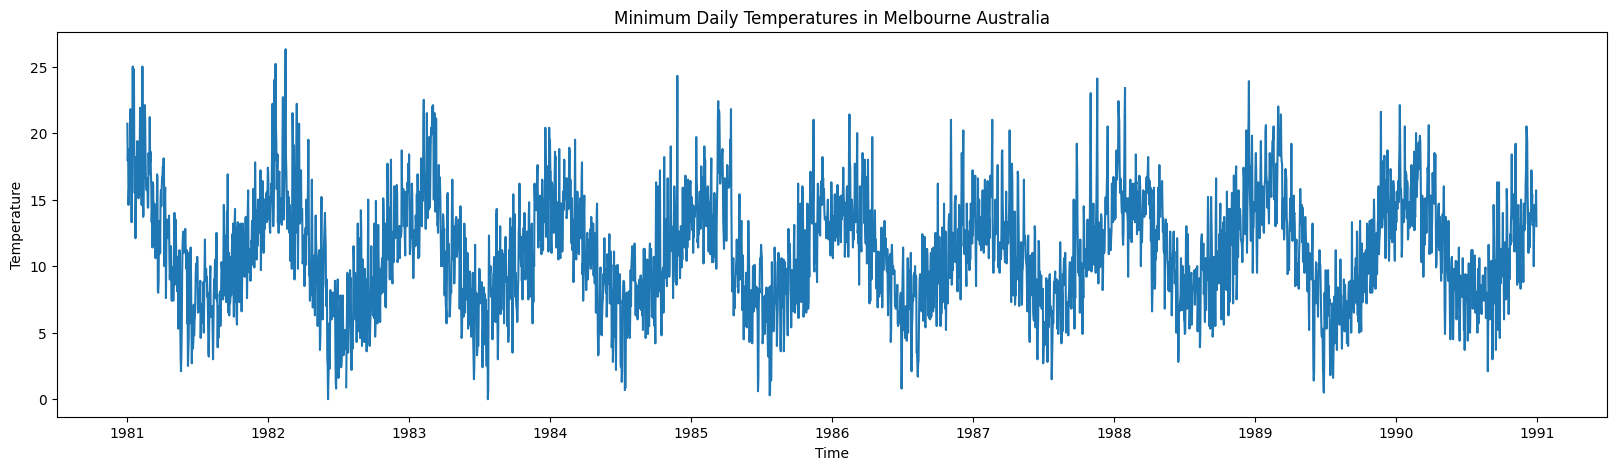

In [7]:
plt.figure(figsize = (20,5))
data["Date"] = pd.to_datetime(data["Date"])
temps = pd.to_numeric(data.iloc[:, 1], errors="coerce")
plt.plot(data["Date"], temps)
plt.title("Minimum Daily Temperatures in Melbourne Australia")
plt.xlabel("Time")
plt.ylabel("Temperature")
plt.show()

In [8]:
train_percentage = 0.67
train_size = int(len(data) * train_percentage)

train = data[:train_size]
test = data[train_size:]

# Renombramos las columnas: 'ds' para fechas y 'y' para el valor (temperatura)
train = train.rename(columns={'Date': 'ds', 'Temp': 'y'})
test = test.rename(columns={'Date': 'ds', 'Temp': 'y'})

print(train.shape)
train.head()
# Salida esperada: (2445, 2)

(2445, 2)


,ds,"Daily minimum temperatures in Melbourne, Australia, 1981-1990"
0,1981-01-01,20.7
1,1981-01-02,17.9
2,1981-01-03,18.8
3,1981-01-04,14.6
4,1981-01-05,15.8


In [10]:
prophet_basic = Prophet()

# Si tuvieras variables externas (ej. humedad), usarías .add_regressor()
# prophet_basic.add_regressor('feature_1') 

# Asegura que el DataFrame tenga exactamente las columnas requeridas por Prophet: 'ds' y 'y'
train_prophet = train.copy()

if "y" not in train_prophet.columns:
    value_col = [c for c in train_prophet.columns if c != "ds"][0]
    train_prophet = train_prophet.rename(columns={value_col: "y"})

train_prophet["y"] = pd.to_numeric(train_prophet["y"], errors="coerce")
train_prophet = train_prophet.dropna(subset=["ds", "y"])

prophet_basic.fit(train_prophet)

17:03:52 - cmdstanpy - INFO - Chain [1] start processing
17:03:52 - cmdstanpy - INFO - Chain [1] done processing


In [11]:
# Creamos un dataframe con las fechas de entrenamiento + las del set de test
prediction_dates = prophet_basic.make_future_dataframe(periods=test.shape[0]+1)
prediction_dates.tail(2)

,ds
3646,1990-12-30
3647,1990-12-31


In [15]:
prophet_basic = Prophet()

# Comentarios del código original sobre análisis multivariado:
# prophet_basic.add_regressor('feature_1') # Si tuviese otras columnas y quisiera hacer un analisis multivariado.
# prophet_basic.add_regressor('feature_2')

train_to_fit = train.copy()

if "y" not in train_to_fit.columns:
    value_col = [c for c in train_to_fit.columns if c != "ds"][0]
    train_to_fit = train_to_fit.rename(columns={value_col: "y"})

train_to_fit["ds"] = pd.to_datetime(train_to_fit["ds"], errors="coerce")
train_to_fit["y"] = pd.to_numeric(train_to_fit["y"], errors="coerce")
train_to_fit = train_to_fit.dropna(subset=["ds", "y"])

prophet_basic.fit(train_to_fit)

17:07:03 - cmdstanpy - INFO - Chain [1] start processing
17:07:03 - cmdstanpy - INFO - Chain [1] done processing


In [16]:
prediction_dates = prophet_basic.make_future_dataframe(periods=test.shape[0]+1)
prediction_dates.tail(2)

# Salida esperada en la imagen:
# 3649  1990-12-30
# 3650  1990-12-31

,ds
3646,1990-12-30
3647,1990-12-31


In [17]:
predictions = prophet_basic.predict(prediction_dates)
predictions.tail(5)

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
3643,1990-12-27,10.367293,9.664043,16.823840,9.757708,11.011013,3.090523,3.090523,3.090523,-0.171305,-0.171305,-0.171305,3.261829,3.261829,3.261829,0.0,0.0,0.0,13.457816
3644,1990-12-28,10.367018,10.280572,17.166113,9.756715,11.011864,3.298507,3.298507,3.298507,-0.039854,-0.039854,-0.039854,3.338362,3.338362,3.338362,0.0,0.0,0.0,13.665526
3645,1990-12-29,10.366744,10.209146,17.222287,9.755721,11.012716,3.383545,3.383545,3.383545,-0.027544,-0.027544,-0.027544,3.411088,3.411088,3.411088,0.0,0.0,0.0,13.750289
3646,1990-12-30,10.366470,10.169700,17.019729,9.754728,11.013553,3.279581,3.279581,3.279581,-0.199397,-0.199397,-0.199397,3.478979,3.478979,3.478979,0.0,0.0,0.0,13.646051
3647,1990-12-31,10.366196,10.466750,17.633679,9.753734,11.014348,3.587770,3.587770,3.587770,0.046664,0.046664,0.046664,3.541105,3.541105,3.541105,0.0,0.0,0.0,13.953966


In [18]:
# Verificación de tipos de datos
predictions[["ds", "yhat"]].dtypes

# Aseguramos que la columna de fecha en test sea datetime para que el merge funcione
test['ds'] = pd.to_datetime(test['ds'])

# Unimos los valores reales (y) con las predicciones (yhat)
results = pd.merge(test, predictions[["ds", "yhat"]], on=["ds"], how='left')

results.tail()

,ds,"Daily minimum temperatures in Melbourne, Australia, 1981-1990",yhat
1200,1990-12-27,14.0,13.457816
1201,1990-12-28,13.6,13.665526
1202,1990-12-29,13.5,13.750289
1203,1990-12-30,15.7,13.646051
1204,1990-12-31,13.0,13.953966


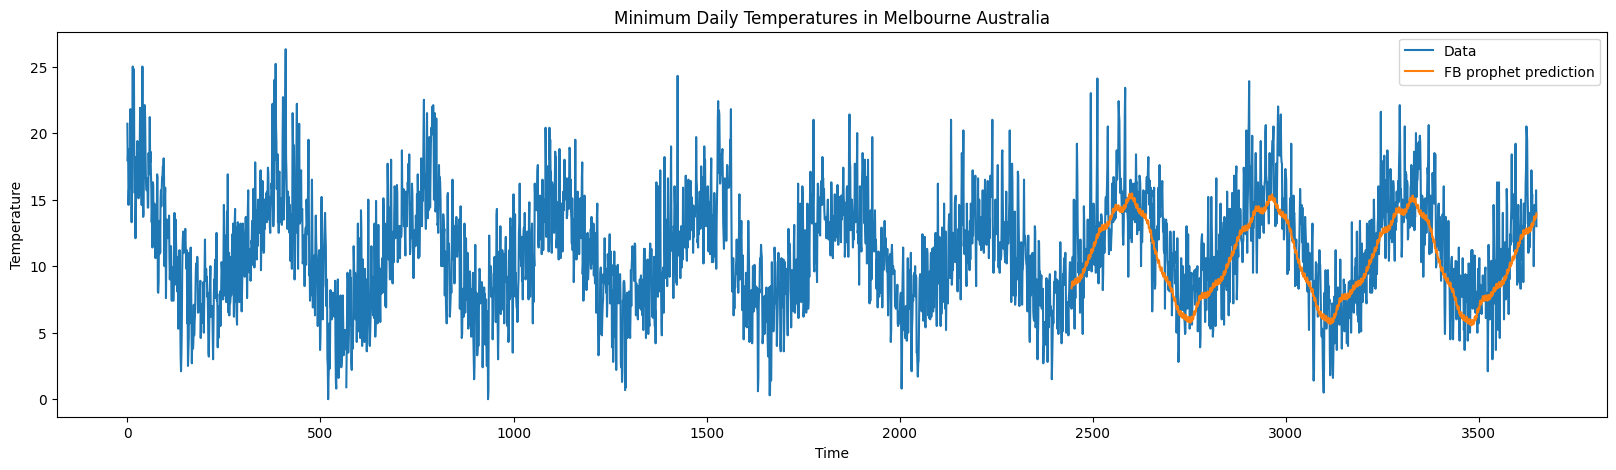

In [23]:
index_start = len(train)
index_end = len(train) + len(test)

plt.figure(figsize=(20, 5))

# Graficamos la serie histórica completa (usar 'temps' si existe, si no tomar la columna de datos)
try:
	data_series = temps
except NameError:
	data_series = pd.to_numeric(data.iloc[:, 1], errors="coerce")

x_data = np.arange(len(data_series))
y_data = np.asarray(data_series, dtype=float)
plt.plot(x_data, y_data, label="Data")

# Graficamos la predicción de Prophet sobre el set de test
x_pred = np.arange(index_start, index_end)
y_pred = np.asarray(results["yhat"], dtype=float)
plt.plot(x_pred, y_pred, label="FB prophet prediction")

plt.title("Minimum Daily Temperatures in Melbourne Australia")
plt.xlabel("Time")
plt.ylabel("Temperature")
plt.legend()
plt.show()

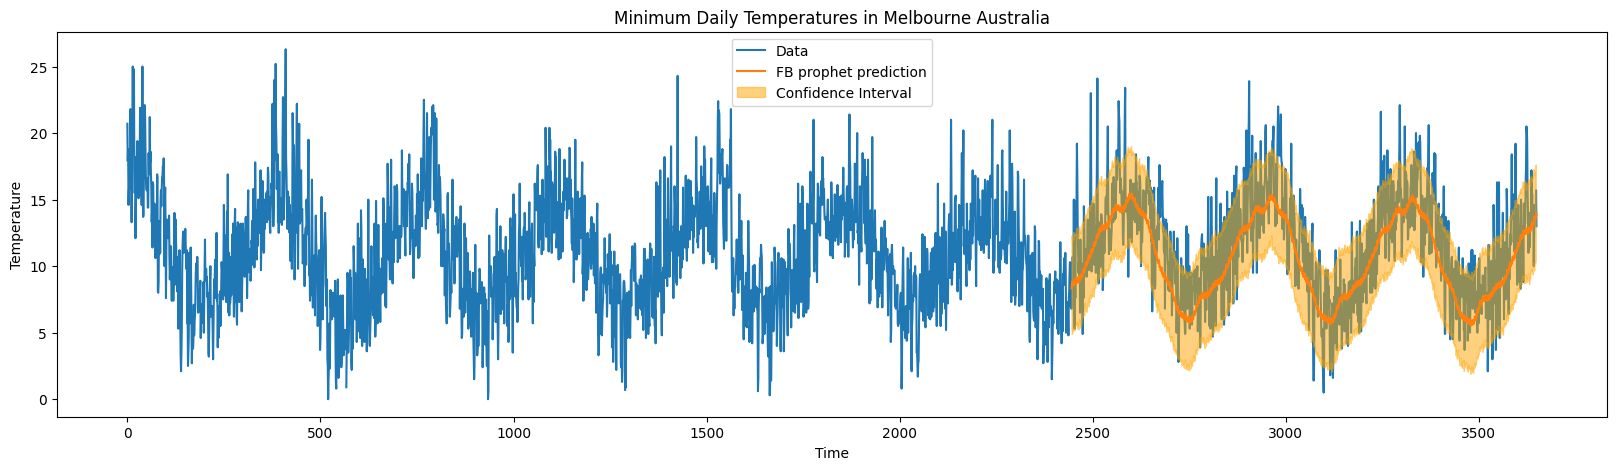

In [31]:
# Definición de índices para el eje X
index_start = len(train)
index_end = len(train) + len(test)

plt.figure(figsize=(20, 5))

# 1. Datos originales
# usar 'temps' (serie numérica) en lugar de una columna que puede no existir como atributo
plt.plot(temps, label="Data", zorder = 1)

# 2. Predicción de Prophet
x_pred = np.arange(index_start, index_end, dtype=int)
y_pred = pd.to_numeric(results["yhat"], errors="coerce").to_numpy(dtype=float)
plt.plot(x_pred, y_pred, label="FB prophet prediction", zorder=2)

# 3. Sombreado de incertidumbre (Intervalos de confianza)
# Aseguramos que los slices estén dentro de los límites del DataFrame 'predictions'
pred_len = len(predictions)
start_idx = max(0, index_start)
end_idx = min(index_end, pred_len)

# Convertir explícitamente a arrays NumPy de tipo float para evitar problemas de tipo
yhat_lower = np.asarray(predictions["yhat_lower"].iloc[start_idx:end_idx].to_numpy(), dtype=float)
yhat_upper = np.asarray(predictions["yhat_upper"].iloc[start_idx:end_idx].to_numpy(), dtype=float)

# Coordenadas X para el sombreado: comienzan en start_idx y tienen la misma longitud que los intervalos
x_fill = np.arange(start_idx, start_idx + len(yhat_lower), dtype=int)

# Solo rellenar si las longitudes coinciden y son mayores a cero
if len(x_fill) > 0 and len(yhat_lower) == len(yhat_upper) == len(x_fill):
    plt.fill_between(
        x_fill,
        yhat_lower,
        yhat_upper,
        color = 'orange',
        alpha=0.5, # Agregamos transparencia para que se vea mejor
        label="Confidence Interval"
    )

plt.title("Minimum Daily Temperatures in Melbourne Australia")
plt.xlabel("Time")
plt.ylabel("Temperature")
plt.legend()
plt.show()